In [4]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

import arviz as az
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig

In [6]:
# filename for nuts -- first wildcard is for chain number 0-3, second for flag XYZ
fname_nuts = '/mnt/ceph/users/vpandya/sapphire_outputs/outputs/numpyro_mix_chain%s_%s_slope4_mzrgas_samples12K.npz'

# filename for aies -- wildcard is for flag
fname_aies = '/mnt/ceph/users/vpandya/sapphire_outputs_referee/outputs/aies20split_mix_%s.npz'


In [5]:
# global plotting options
params_free = ["A_M","alpha0_M","A_E","alpha0_E","A_SF","alpha0_SF","A_Z","alpha0_Z"]
flag_labels = {'100':r'SMHM','110':r'SMHM+f$_{\rm ISM}$','111':r'SMHM+f$_{\rm ISM}$+MZR'}
color_nuts = 'rose'
color_aies = 'blue'

In [23]:
### adapt sapphire/visualization/numpyro_plots.py 

def multicorner(flag,fname_nuts,fname_aies):

    # initialize chainconsumer
    consumer = ChainConsumer()

    ### first plot AIES (all walkers in single file)
    npz_aies = np.load(fname_aies%flag,allow_pickle=True)
    samples_dict_aies = {k: npz_aies['samples'].item()[k] for k in params_free}
    samples_df_aies = pd.DataFrame(samples_dict_aies)    

    consumer.add_chain(Chain(samples=samples_df_aies, name='AIES',color=color_aies,shade_alpha=0.2))

    ### next plot NUTS (merging different chains from different files)
    chains_nuts = {} 
    
    for cnum in range(0,4):

        npz_nuts = np.load(fname_nuts%(cnum,flag),allow_pickle=True)
    
        samples_dict_nuts = {k: npz_nuts['samples'].item()[k] for k in params_free}
        samples_df_nuts = pd.DataFrame(samples_dict_nuts)
        chains_nuts[cnum] = samples_df_nuts

    samples_df_nuts = pd.concat(chains_nuts.values(), ignore_index=True) 

    consumer.add_chain(Chain(samples=samples_df_nuts, name='NUTS',color=color_nuts,shade_alpha=0.2))

    # TO DO: generalize with user inputting these
    consumer.set_plot_config(PlotConfig(extents={'A_M':(-2.1,1.1),'alpha0_M':(-4.1,0.1),
                                                 'A_E':(-2.1,0.1),'alpha0_E':(-4.1,0.1),
                                                 'A_SF':(-0.1,1.2),'alpha0_SF':(-4.1,0.1),
                                                 'A_Z':(-2.1,0.1),'alpha0_Z':(-4.1,0.1),},
                                        labels={'A_M':r'$A_M$','alpha0_M':r'$\alpha_M^0$',
                                                'A_E':r'$A_E$','alpha0_E':r'$\alpha_E^0$',
                                                'A_SF':r'$A_{\rm SF}$','alpha0_SF':r'$\alpha_{\rm SF}^0$',
                                                'A_Z':r'$A_Z$','alpha0_Z':r'$\alpha_Z^0$'},
                                        label_font_size=16,
                                        legend_location=(0,0),legend_kwargs={'bbox_to_anchor':(3.5,1.0),'fontsize':30}))

    # create plot
    fig = consumer.plotter.plot()  
    axes = np.reshape(fig.axes,(8,8))
    
    fig.suptitle(flag_labels[flag],fontsize=32,y=0.93)

    return fig

    
    

Parameter A_M in chain AIES is not constrained
Parameter A_M in chain NUTS is not constrained
Parameter A_SF in chain NUTS is not constrained
Parameter A_Z in chain AIES is not constrained
Parameter alpha0_Z in chain NUTS is not constrained


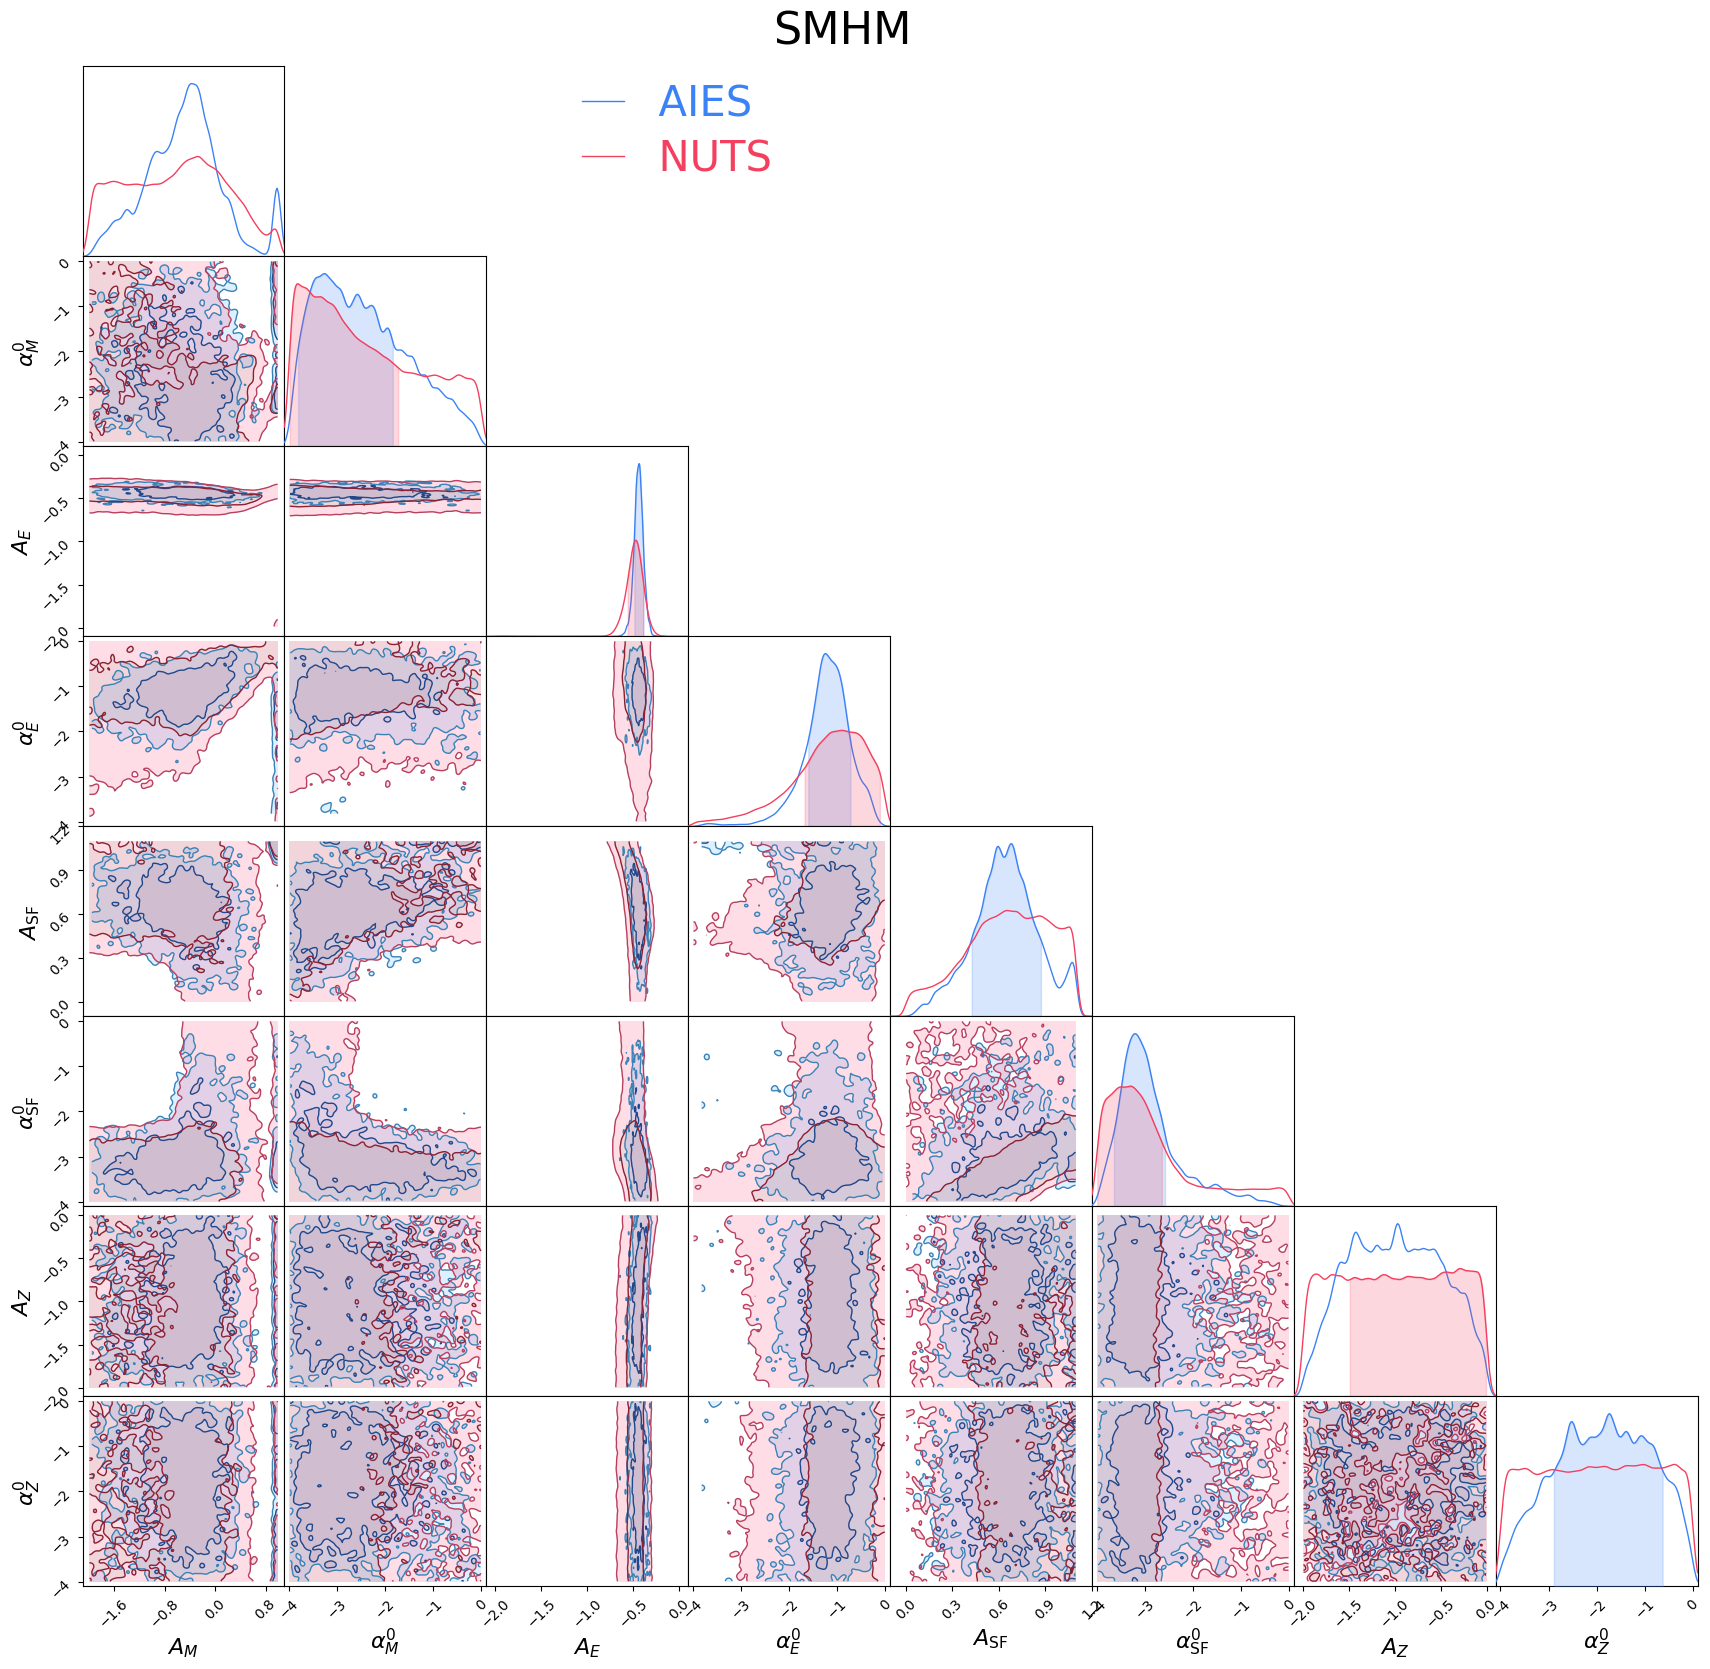

In [29]:
fig = multicorner('100',fname_nuts,fname_aies) # or do 111, 110 

# plt.savefig('compare_aies_nuts_100.png',dpi=120,bbox_inches='tight',facecolor='w')